In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!ls

analysis_results.ipynb	q_tensor_best_fibernet_config_high_density.qmd	scripts
data			results


In [3]:
from pathlib import Path
import json
import re
import pandas as pd

broad = {
    "densities": [8, 16, 24, 32],
    "lambda_tvas": [0.0, 1e-11, 1e-9, 1e-6, 1e-5],
    "learning_rates": [1e-3, 5e-4, 1e-4],
    "models": ["alpha", "q_alpha", "q_direct"],
    "n_iter": 30000,
}

# Robustly find the results folder
possible_results_dirs = [
    Path("results"),
    Path.cwd() / "results",
]

RESULTS_DIR = None
for p in possible_results_dirs:
    if p.exists() and p.is_dir():
        RESULTS_DIR = p
        break

if RESULTS_DIR is None:
    matches = list(Path.cwd().rglob("results"))
    matches = [m for m in matches if m.is_dir() and any(m.glob("density*"))]
    if not matches:
        raise FileNotFoundError("Could not find a results/ directory containing density* folders.")
    RESULTS_DIR = matches[0]

print("Using RESULTS_DIR:", RESULTS_DIR.resolve())


def decode_token(raw: str) -> float:
    """
    Handles tokens like:
      0          -> 0.0
      1em06      -> 1e-06
      1em05      -> 1e-05
      0p001      -> 0.001
      0p0005     -> 0.0005
    """
    raw = raw.strip()
    raw = raw.replace("p", ".")
    raw = re.sub(r"(\d+)em(\d+)", r"\1e-\2", raw)
    return float(raw)


def flatten_json(obj, prefix=""):
    """
    Flatten dicts.
    Lists are kept as lists, and also expanded into indexed columns.
    """
    out = {}

    if isinstance(obj, dict):
        for k, v in obj.items():
            key = f"{prefix}.{k}" if prefix else str(k)
            out.update(flatten_json(v, key))

    elif isinstance(obj, list):
        out[prefix] = obj
        for i, v in enumerate(obj):
            key = f"{prefix}_{i}"
            if isinstance(v, dict):
                out.update(flatten_json(v, key))
            else:
                out[key] = v

    else:
        out[prefix] = obj

    return out


def parse_metadata_from_path(json_path: Path) -> dict:
    parts = json_path.relative_to(RESULTS_DIR).parts

    meta = {
        "density": None,
        "lambda_tva": None,
        "learning_rate": None,
        "n_iter": None,
        "batch_size": None,
        "model": None,
        "json_kind": json_path.stem,
        "json_file": json_path.name,
        "path": str(json_path),
    }

    for part in parts:
        if part.startswith("density"):
            meta["density"] = int(part.removeprefix("density"))

        elif part.startswith("lambda_tva"):
            meta["lambda_tva"] = decode_token(part.removeprefix("lambda_tva"))

        elif part.startswith("lr"):
            meta["learning_rate"] = decode_token(part.removeprefix("lr"))

        elif part.startswith("niter"):
            meta["n_iter"] = int(part.removeprefix("niter"))

        elif part.startswith("batch"):
            meta["batch_size"] = int(part.removeprefix("batch"))

        elif part in broad["models"]:
            meta["model"] = part

    return meta


rows = []

for json_path in sorted(RESULTS_DIR.rglob("*.json")):
    if json_path.stem in ["config", "summary"]:
        continue
    try:
        with open(json_path, "r") as f:
            payload = json.load(f)

        meta = parse_metadata_from_path(json_path)
        flat = flatten_json(payload)

        rows.append({**meta, **flat})

    except Exception as e:
        rows.append({
            "path": str(json_path),
            "json_file": json_path.name,
            "json_kind": json_path.stem,
            "parse_error": repr(e),
        })

df_json = pd.DataFrame(rows)

sort_cols = [
    "density",
    "lambda_tva",
    "learning_rate",
    "n_iter",
    "batch_size",
    "model",
    "json_kind",
]
sort_cols = [c for c in sort_cols if c in df_json.columns]

df_json = df_json.sort_values(sort_cols).reset_index(drop=True)

print("Parsed JSON files:", len(df_json))
df_json.head()

Using RESULTS_DIR: /home/theapparatus/Desktop/Universidad/2026-1/Taller de Ing/Repofinal/Experiments/delta-fibernet-experiments/experiments/q_tensor_best_fibernet_config_high_density/results
Parsed JSON files: 197


,density,lambda_tva,learning_rate,n_iter,batch_size,model,json_kind,json_file,path,angular_error_deg_mean,...,activation_observed_rmse_by_map_3,activation_observed_rmse_by_map_4,activation_observed_rmse_mean,final_loss,final_loss_data,final_loss_pde,final_loss_regu_orient,final_loss_regu_orient_weighted,train_time_seconds,train_time_minutes
0,8,0.0,0.0001,30000,32,alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p0001/niter300...,38.008629,...,0.178708,0.199705,0.185184,0.000152,0.000145,0.070946,0.223523,0.0,278.955929,4.649265
1,8,0.0,0.0001,30000,32,q_alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p0001/niter300...,38.008629,...,0.178708,0.199705,0.185184,0.000152,0.000145,0.070946,0.488269,0.0,279.870789,4.664513
2,8,0.0,0.0001,30000,32,q_direct,metrics,metrics.json,results/density8/lambda_tva0/lr0p0001/niter300...,39.281044,...,0.180197,0.206299,0.186803,0.000159,0.000148,0.117342,0.752251,0.0,279.290893,4.654848
3,8,0.0,0.0005,30000,32,alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p0005/niter300...,32.635853,...,0.115692,0.087147,0.107265,0.000051,0.000045,0.056235,0.530001,0.0,281.752743,4.695879
4,8,0.0,0.0005,30000,32,q_alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p0005/niter300...,32.635853,...,0.115692,0.087147,0.107265,0.000051,0.000045,0.056235,0.926204,0.0,283.966037,4.732767


In [4]:
df_metrics = df_json[df_json["json_kind"] == "metrics"].copy()

print("Metrics rows:", len(df_metrics))

df_stats = df_metrics[[
    "density",
    "lambda_tva",
    "learning_rate",
    "n_iter",
    "batch_size",
    "model",
    "angular_error_deg_mean",
    "angular_error_deg_median",
    "angular_error_deg_p25",
    "angular_error_deg_p75",
    "angular_error_deg_p95",
    "activation_observed_rmse_mean",
    "final_loss",
    "train_time_seconds",
    "train_time_minutes",
    "path",
]].copy()

Metrics rows: 197


In [5]:
df_stats

,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
0,8,0.000000e+00,0.0001,30000,32,alpha,38.008629,35.199108,13.569359,60.894295,83.386208,0.185184,0.000152,278.955929,4.649265,results/density8/lambda_tva0/lr0p0001/niter300...
1,8,0.000000e+00,0.0001,30000,32,q_alpha,38.008629,35.199108,13.569359,60.894295,83.386208,0.185184,0.000152,279.870789,4.664513,results/density8/lambda_tva0/lr0p0001/niter300...
2,8,0.000000e+00,0.0001,30000,32,q_direct,39.281044,37.740135,15.530643,61.139778,83.475983,0.186803,0.000159,279.290893,4.654848,results/density8/lambda_tva0/lr0p0001/niter300...
3,8,0.000000e+00,0.0005,30000,32,alpha,32.635853,27.333160,9.101925,52.919479,80.477226,0.107265,0.000051,281.752743,4.695879,results/density8/lambda_tva0/lr0p0005/niter300...
4,8,0.000000e+00,0.0005,30000,32,q_alpha,32.635853,27.333160,9.101925,52.919479,80.477226,0.107265,0.000051,283.966037,4.732767,results/density8/lambda_tva0/lr0p0005/niter300...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,256,1.000000e-09,0.0010,30000,32,q_alpha,30.870529,23.929901,7.479435,50.844246,79.627396,0.080996,0.000027,865.267637,14.421127,results/density256/lambda_tva1em09/lr0p001/nit...
193,256,1.000000e-09,0.0010,30000,32,q_direct,25.144665,15.409401,6.225394,39.560440,77.393028,0.080126,0.000030,879.392090,14.656535,results/density256/lambda_tva1em09/lr0p001/nit...
194,256,1.000000e-05,0.0010,30000,32,alpha,34.775314,30.689875,13.623322,52.961540,80.286797,0.082939,0.000032,877.912719,14.631879,results/density256/lambda_tva1em05/lr0p001/nit...
195,256,1.000000e-05,0.0010,30000,32,q_alpha,34.870621,30.840824,13.631529,53.132111,80.487900,0.076516,0.000027,881.440326,14.690672,results/density256/lambda_tva1em05/lr0p001/nit...


In [6]:
df_stats.to_csv("results.csv", index=False)

In [5]:
df_stats.loc[df_stats["model"] == "alpha"].sort_values(by="angular_error_deg_mean").head(7)


,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
184,128,1.000000e-09,0.001,30000,32,alpha,23.151266,12.827129,5.206154,35.540054,75.292130,0.081974,0.000029,422.520080,7.042001,results/density128/lambda_tva1em09/lr0p001/nit...
118,24,1.000000e-09,0.001,30000,32,alpha,28.986380,21.303156,7.304455,46.809769,77.220383,0.082282,0.000029,291.649227,4.860820,results/density24/lambda_tva1em09/lr0p001/nite...
100,24,0.000000e+00,0.001,30000,32,alpha,29.143484,21.540775,7.259034,47.062820,77.642799,0.080125,0.000037,291.404613,4.856744,results/density24/lambda_tva0/lr0p001/niter300...
51,16,0.000000e+00,0.001,30000,32,alpha,29.187862,22.235882,8.451580,45.570747,76.152534,0.078804,0.000029,272.019702,4.533662,results/density16/lambda_tva0/lr0p001/niter300...
109,24,1.000000e-11,0.001,30000,32,alpha,29.213219,21.564514,7.225470,47.413948,77.561211,0.087979,0.000027,289.728335,4.828806,results/density24/lambda_tva1em11/lr0p001/nite...
73,16,1.000000e-09,0.001,30000,32,alpha,29.219042,22.378220,8.320795,45.720638,76.169952,0.082661,0.000026,277.143160,4.619053,results/density16/lambda_tva1em09/lr0p001/nite...
60,16,1.000000e-11,0.001,30000,32,alpha,29.345583,22.460896,8.568847,45.834846,76.258026,0.078520,0.000031,271.453550,4.524226,results/density16/lambda_tva1em11/lr0p001/nite...


In [35]:
df_stats.loc[df_stats["model"] == "q_alpha"].sort_values(by="angular_error_deg_mean").head(7)


,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
185,128,1.000000e-09,0.001,30000,32,q_alpha,22.799221,12.790684,5.109925,34.721413,74.570457,0.076978,0.000027,423.231133,7.053852,results/density128/lambda_tva1em09/lr0p001/nit...
61,16,1.000000e-11,0.001,30000,32,q_alpha,29.116449,22.263088,8.299914,45.454525,76.117935,0.086670,0.000029,272.401807,4.540030,results/density16/lambda_tva1em11/lr0p001/nite...
110,24,1.000000e-11,0.001,30000,32,q_alpha,29.116898,21.458797,7.335594,47.276863,77.400627,0.080675,0.000032,292.957757,4.882629,results/density24/lambda_tva1em11/lr0p001/nite...
101,24,0.000000e+00,0.001,30000,32,q_alpha,29.143484,21.540775,7.259034,47.062820,77.642799,0.080125,0.000037,292.359100,4.872652,results/density24/lambda_tva0/lr0p001/niter300...
52,16,0.000000e+00,0.001,30000,32,q_alpha,29.187862,22.235882,8.451580,45.570747,76.152534,0.078804,0.000029,278.008505,4.633475,results/density16/lambda_tva0/lr0p001/niter300...
119,24,1.000000e-09,0.001,30000,32,q_alpha,29.189631,21.501987,7.286719,47.208073,77.818726,0.078839,0.000028,292.938002,4.882300,results/density24/lambda_tva1em09/lr0p001/nite...
74,16,1.000000e-09,0.001,30000,32,q_alpha,29.255039,22.382553,8.469244,45.676762,76.170395,0.081016,0.000027,273.567893,4.559465,results/density16/lambda_tva1em09/lr0p001/nite...


In [36]:
df_stats.loc[df_stats["model"] == "q_direct"].sort_values(by="angular_error_deg_mean").head(15)

,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
193,256,1.000000e-09,0.0010,30000,32,q_direct,25.144665,15.409401,6.225394,39.560440,77.393028,0.080126,0.000030,879.392090,14.656535,results/density256/lambda_tva1em09/lr0p001/nit...
8,8,0.000000e+00,0.0010,30000,32,q_direct,25.174271,15.525923,6.719065,38.543678,76.715042,0.076802,0.000029,283.554176,4.725903,results/density8/lambda_tva0/lr0p001/niter3000...
156,32,1.000000e-11,0.0010,30000,32,q_direct,25.700560,15.399315,6.353385,40.004345,79.038292,0.078248,0.000031,304.826651,5.080444,results/density32/lambda_tva1em11/lr0p001/nite...
147,32,0.000000e+00,0.0010,30000,32,q_direct,26.008234,16.208675,6.239903,41.252289,78.476791,0.085856,0.000030,303.494675,5.058245,results/density32/lambda_tva0/lr0p001/niter300...
75,16,1.000000e-09,0.0010,30000,32,q_direct,26.070635,15.893880,6.383589,40.458267,79.794441,0.079159,0.000033,275.583634,4.593061,results/density16/lambda_tva1em09/lr0p001/nite...
168,32,1.000000e-09,0.0010,30000,32,q_direct,26.427555,15.370642,5.948424,42.875626,80.847954,0.075131,0.000031,305.930425,5.098840,results/density32/lambda_tva1em09/lr0p001/nite...
111,24,1.000000e-11,0.0010,30000,32,q_direct,26.671558,16.623257,6.962029,41.997307,79.853745,0.085390,0.000035,295.028228,4.917137,results/density24/lambda_tva1em11/lr0p001/nite...
190,256,1.000000e-09,0.0010,20000,32,q_direct,27.117109,17.869495,7.134289,42.651512,80.012260,0.103943,0.000070,473.896568,7.898276,results/density256/lambda_tva1em09/lr0p001/nit...
62,16,1.000000e-11,0.0010,30000,32,q_direct,27.242846,16.672226,6.582675,44.094013,81.145424,0.076647,0.000033,282.281510,4.704692,results/density16/lambda_tva1em11/lr0p001/nite...
53,16,0.000000e+00,0.0010,30000,32,q_direct,27.275887,16.815193,6.584068,42.556557,82.565727,0.077459,0.000030,279.656323,4.660939,results/density16/lambda_tva0/lr0p001/niter300...


Text(0, 0.5, 'angular_error_deg_mean')

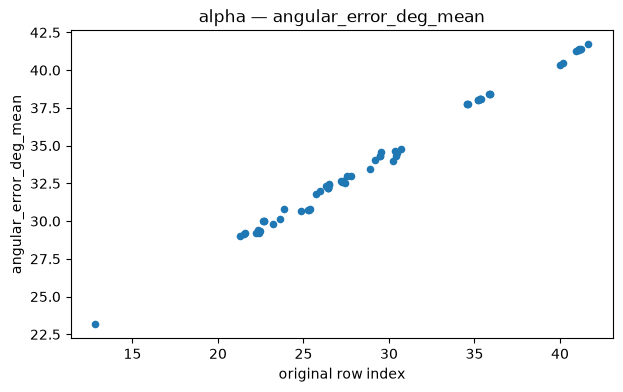

In [37]:
model_name = "alpha"

plot_df = (
    df_stats.loc[df_stats["model"] == model_name]
    .sort_values(by="angular_error_deg_mean")
    .reset_index()
)

ax = plot_df.plot.scatter(
    x="angular_error_deg_median",
    y="angular_error_deg_mean",
    figsize=(7, 4),
    title=f"{model_name} — angular_error_deg_mean"
)

ax.set_xlabel("original row index")
ax.set_ylabel("angular_error_deg_mean")

In [38]:
df_stats.describe()

,density,lambda_tva,learning_rate,n_iter,batch_size,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes
count,197.000000,1.970000e+02,197.000000,197.000000,197.0,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,32.243655,2.289606e-06,0.000581,29307.106599,32.0,33.818938,28.704041,11.770832,52.805160,80.977802,0.126667,0.000081,304.047323,5.067455
std,48.345077,4.039516e-06,0.000380,3136.088532,0.0,4.879368,7.841746,3.822193,7.037645,2.436999,0.046240,0.000057,109.897009,1.831617
min,8.000000,0.000000e+00,0.000100,10000.000000,32.0,22.799221,12.790684,5.109925,34.721413,74.570457,0.074243,0.000026,91.378297,1.522972
25%,16.000000,1.000000e-11,0.000100,30000.000000,32.0,29.806391,22.456373,8.270984,47.720253,79.627396,0.082939,0.000032,278.046541,4.634109
50%,24.000000,1.000000e-09,0.000500,30000.000000,32.0,33.587212,29.076576,13.268006,51.757828,80.829880,0.109617,0.000054,285.310630,4.755177
75%,32.000000,1.000000e-06,0.001000,30000.000000,32.0,38.040764,35.269665,13.822485,60.894295,83.207291,0.186803,0.000157,295.270910,4.921182
max,256.000000,1.000000e-05,0.001000,30000.000000,32.0,44.033920,45.291508,21.031759,66.386589,85.393021,0.201198,0.000173,882.457398,14.707623


In [39]:
df_metrics[df_metrics["density"] == 32].columns

Index(['density', 'lambda_tva', 'learning_rate', 'n_iter', 'batch_size',
       'model', 'json_kind', 'json_file', 'path', 'angular_error_deg_mean',
       'angular_error_deg_median', 'angular_error_deg_p25',
       'angular_error_deg_p75', 'angular_error_deg_p95',
       'angular_error_deg_max', 'activation_observed_rmse_by_map',
       'activation_observed_rmse_by_map_0',
       'activation_observed_rmse_by_map_1',
       'activation_observed_rmse_by_map_2',
       'activation_observed_rmse_by_map_3',
       'activation_observed_rmse_by_map_4', 'activation_observed_rmse_mean',
       'final_loss', 'final_loss_data', 'final_loss_pde',
       'final_loss_regu_orient', 'final_loss_regu_orient_weighted',
       'train_time_seconds', 'train_time_minutes'],
      dtype='str')

In [40]:
def plot_error_histogram(
    df,
    error_col="angular_error_deg_mean",
    lambda_tvas=None,
    density=None,
    model=None,
    learning_rate=None,
    bins=20,
    figsize=None,
    sharex=True,
    sharey=False,
):
    """
    Plot histograms of an error metric, optionally filtered by lambda_tva,
    density, model, and learning_rate.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the experiment results.
        Expected columns include:
        - 'lambda_tva'
        - error_col, e.g. 'angular_error_deg_mean'

    error_col : str
        Column containing the error values to plot.

    lambda_tvas : None, float, int, or list
        Lambda TVA values to include.
        If None, all available lambda_tva values are used.

    density : None, int, or list
        Optional density filter.

    model : None, str, or list
        Optional model filter, e.g. "alpha", "q_alpha", "q_direct".

    learning_rate : None, float, or list
        Optional learning rate filter.

    bins : int
        Number of histogram bins.

    figsize : tuple or None
        Figure size. If None, chosen automatically.

    sharex, sharey : bool
        Whether subplots share x/y axes.

    Returns
    -------
    fig, axes : matplotlib Figure and axes
    """

    required_cols = ["lambda_tva", error_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.copy()

    def _as_list(x):
        if x is None:
            return None
        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            return list(x)
        return [x]

    def _filter_exact_or_close(data, col, values):
        values = _as_list(values)
        if values is None:
            return data

        mask = np.zeros(len(data), dtype=bool)

        for v in values:
            if pd.api.types.is_numeric_dtype(data[col]):
                mask |= np.isclose(data[col].astype(float), float(v), rtol=1e-12, atol=1e-15)
            else:
                mask |= data[col].eq(v)

        return data.loc[mask].copy()

    # General optional filters
    if density is not None:
        data = data[data["density"].isin(_as_list(density))]

    if model is not None:
        data = data[data["model"].isin(_as_list(model))]

    if learning_rate is not None:
        data = _filter_exact_or_close(data, "learning_rate", learning_rate)

    # If lambda_tvas is None, use every available option
    if lambda_tvas is None:
        lambda_tvas = sorted(data["lambda_tva"].dropna().unique())
    else:
        lambda_tvas = _as_list(lambda_tvas)

    data = _filter_exact_or_close(data, "lambda_tva", lambda_tvas)

    if data.empty:
        raise ValueError("No data left after applying the filters.")

    n_lambdas = len(lambda_tvas)

    if figsize is None:
        figsize = (6, 3.5 * n_lambdas)

    fig, axes = plt.subplots(
        n_lambdas,
        1,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, lam in zip(axes, lambda_tvas):
        sub = data[np.isclose(data["lambda_tva"].astype(float), float(lam), rtol=1e-12, atol=1e-15)]
        values = sub[error_col].dropna()

        ax.hist(values, bins=bins, edgecolor="black", alpha=0.75)

        ax.set_title(
            f"Histogram of {error_col} | lambda_tva = {lam:g} | n = {len(values)}"
        )
        ax.set_xlabel(error_col)
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, axes

(<Figure size 600x1750 with 5 Axes>,
 array([<Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 0 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-11 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-09 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-06 | n = 2'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-05 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>],
       dtype=object))

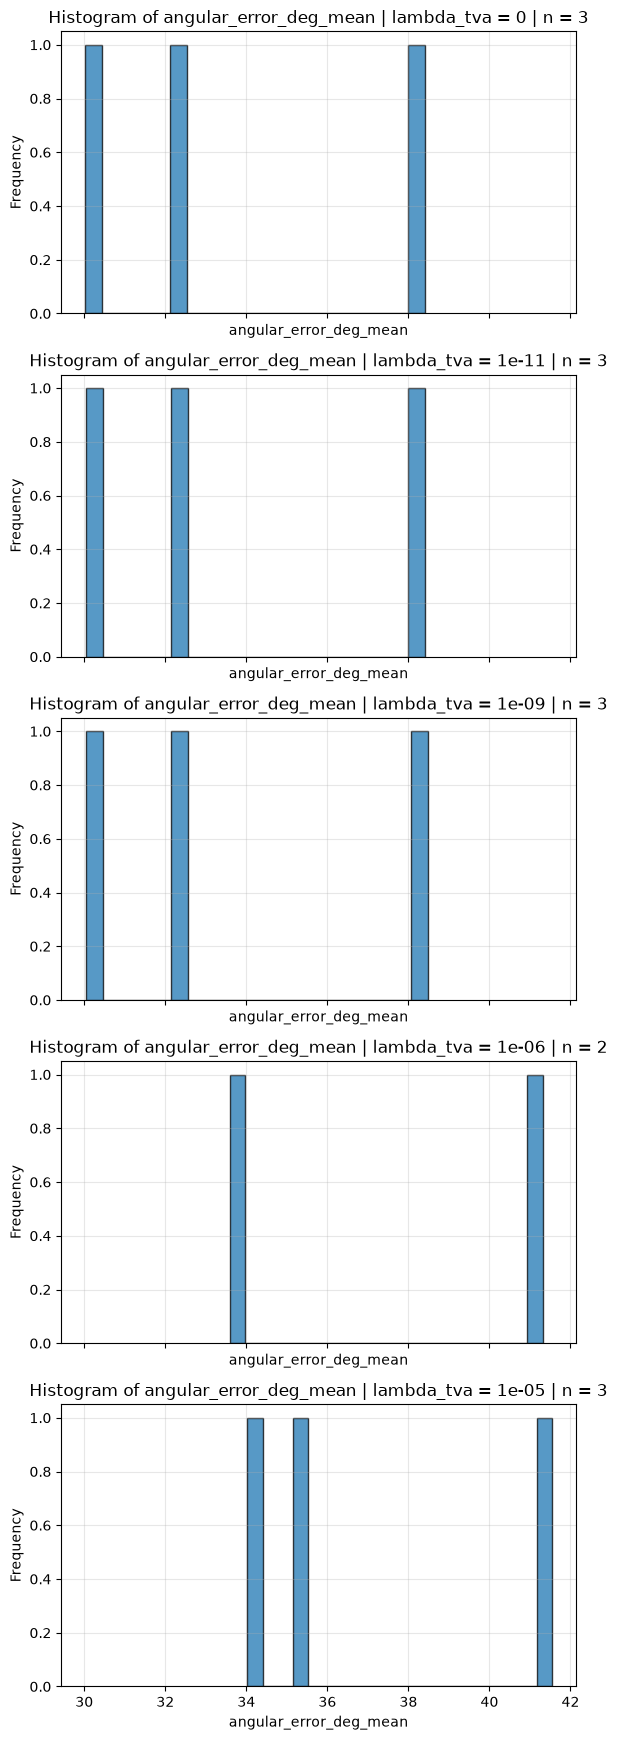

In [41]:
plot_error_histogram(
    df_metrics,
    error_col="angular_error_deg_mean",
    model="q_alpha",
    density=32,
)

In [ ]:
# Filter by model and density
plot_error_histogram(
    df_metrics,
    model="q_direct",
    bins=100
)